Training samples: 120
Testing samples: 30

Hidden Layers: [8] | Activation: relu
Test Accuracy: 0.9333
Test Loss: 0.2075


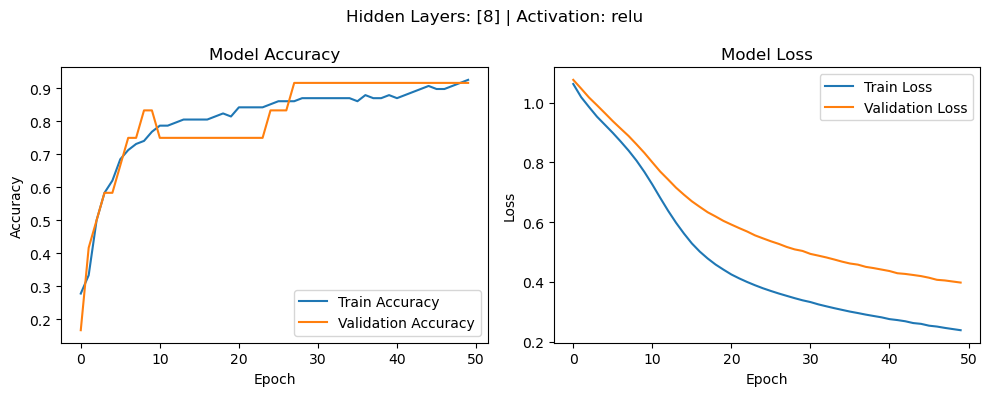

-------------------------------------------------------
Hidden Layers : [8]
Activation    : relu
Test Accuracy : 0.9333
Test Loss     : 0.2075
-------------------------------------------------------

Hidden Layers: [8] | Activation: tanh
Test Accuracy: 0.9333
Test Loss: 0.2099


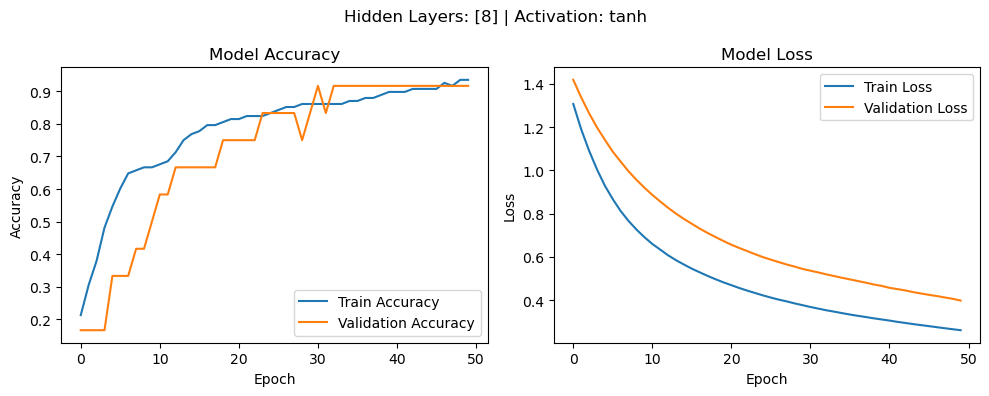

-------------------------------------------------------
Hidden Layers : [8]
Activation    : tanh
Test Accuracy : 0.9333
Test Loss     : 0.2099
-------------------------------------------------------

Hidden Layers: [8] | Activation: sigmoid
Test Accuracy: 0.9333
Test Loss: 0.4754


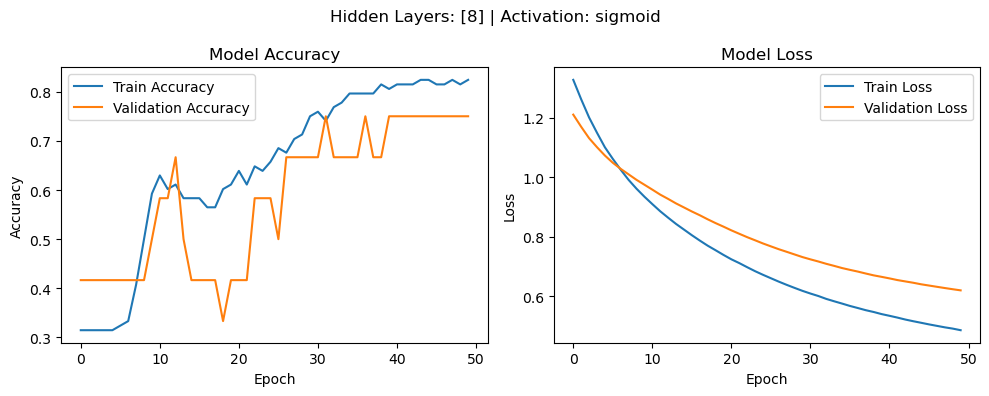

-------------------------------------------------------
Hidden Layers : [8]
Activation    : sigmoid
Test Accuracy : 0.9333
Test Loss     : 0.4754
-------------------------------------------------------

Hidden Layers: [16, 8] | Activation: relu
Test Accuracy: 1.0000
Test Loss: 0.0672


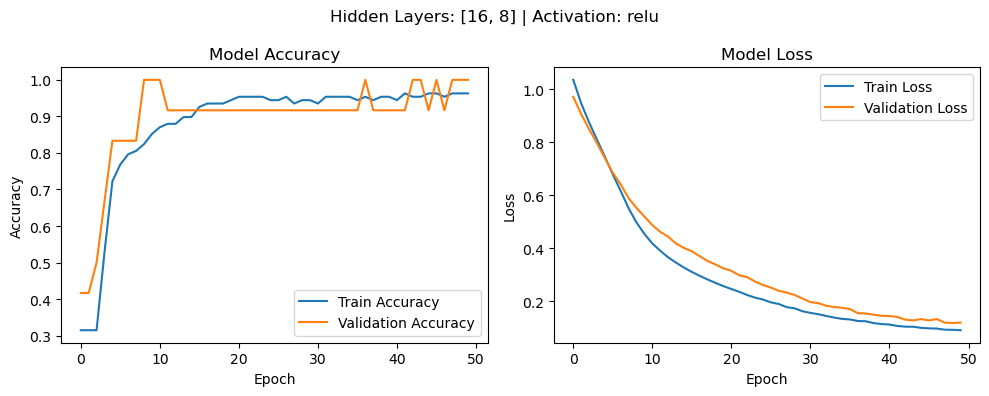

-------------------------------------------------------
Hidden Layers : [16, 8]
Activation    : relu
Test Accuracy : 1.0000
Test Loss     : 0.0672
-------------------------------------------------------

Hidden Layers: [16, 8] | Activation: tanh
Test Accuracy: 0.9667
Test Loss: 0.0851


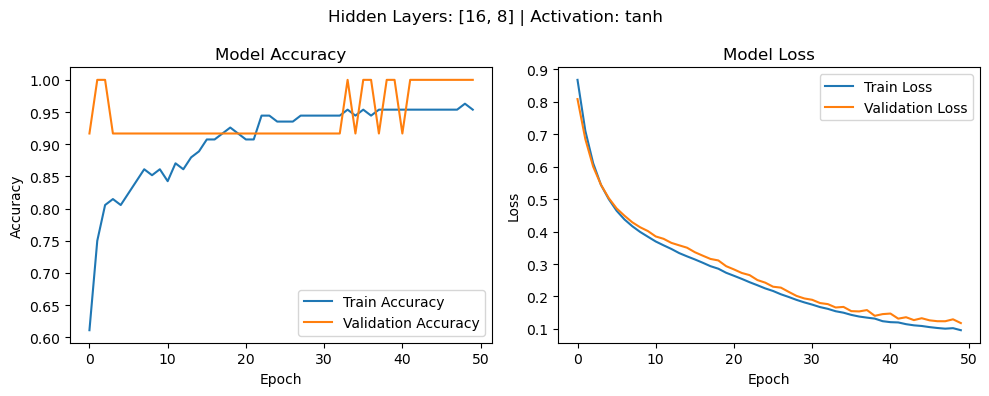

-------------------------------------------------------
Hidden Layers : [16, 8]
Activation    : tanh
Test Accuracy : 0.9667
Test Loss     : 0.0851
-------------------------------------------------------

Hidden Layers: [16, 8] | Activation: sigmoid
Test Accuracy: 0.9333
Test Loss: 0.4175


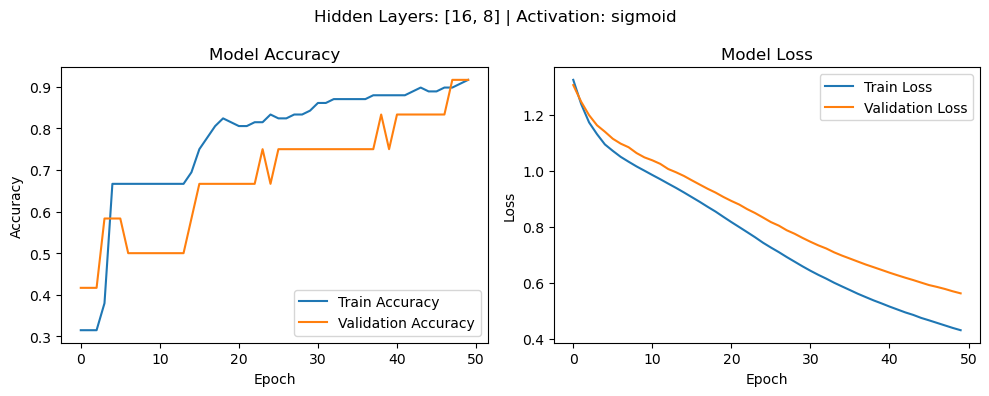

-------------------------------------------------------
Hidden Layers : [16, 8]
Activation    : sigmoid
Test Accuracy : 0.9333
Test Loss     : 0.4175
-------------------------------------------------------

Hidden Layers: [32, 16, 8] | Activation: relu
Test Accuracy: 1.0000
Test Loss: 0.0462


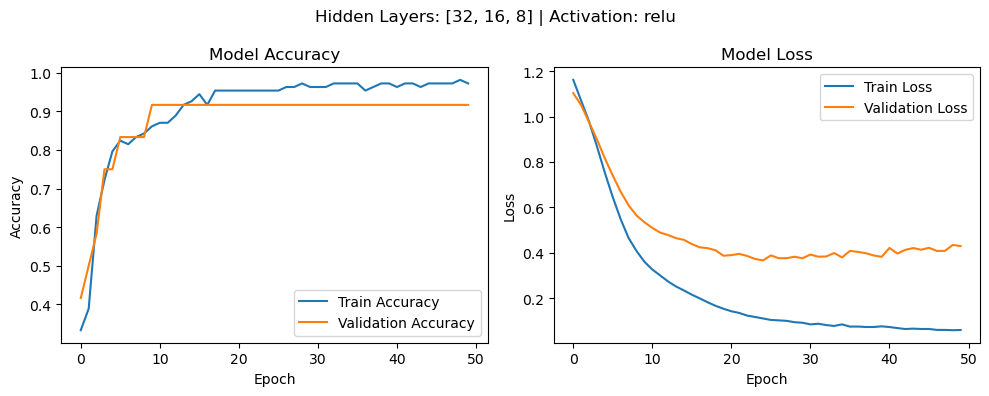

-------------------------------------------------------
Hidden Layers : [32, 16, 8]
Activation    : relu
Test Accuracy : 1.0000
Test Loss     : 0.0462
-------------------------------------------------------

Hidden Layers: [32, 16, 8] | Activation: tanh
Test Accuracy: 1.0000
Test Loss: 0.0388


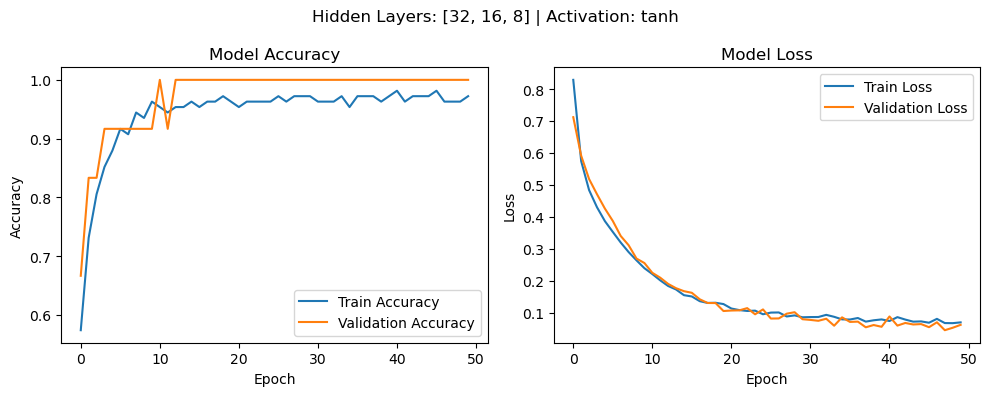

-------------------------------------------------------
Hidden Layers : [32, 16, 8]
Activation    : tanh
Test Accuracy : 1.0000
Test Loss     : 0.0388
-------------------------------------------------------

Hidden Layers: [32, 16, 8] | Activation: sigmoid
Test Accuracy: 0.9333
Test Loss: 0.4209


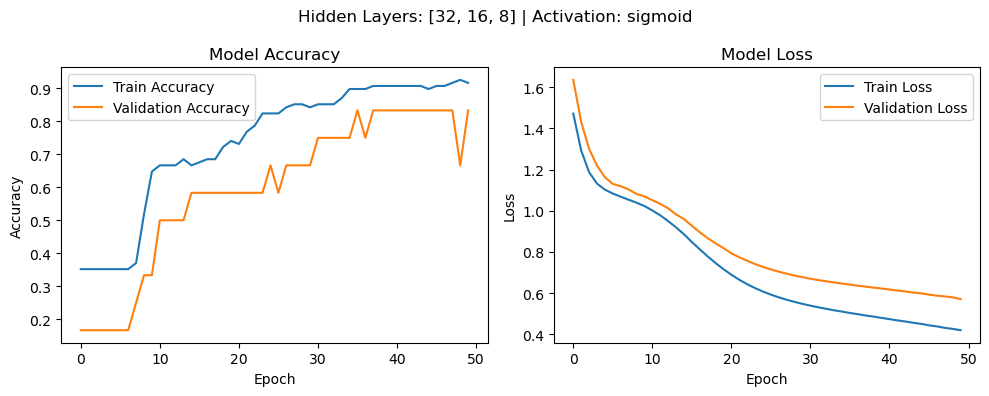

-------------------------------------------------------
Hidden Layers : [32, 16, 8]
Activation    : sigmoid
Test Accuracy : 0.9333
Test Loss     : 0.4209
-------------------------------------------------------


FINAL MLP RESULTS
Hidden Layers: [8]             Activation: relu     Accuracy: 0.9333 Loss: 0.2075
Hidden Layers: [8]             Activation: tanh     Accuracy: 0.9333 Loss: 0.2099
Hidden Layers: [8]             Activation: sigmoid  Accuracy: 0.9333 Loss: 0.4754
Hidden Layers: [16, 8]         Activation: relu     Accuracy: 1.0000 Loss: 0.0672
Hidden Layers: [16, 8]         Activation: tanh     Accuracy: 0.9667 Loss: 0.0851
Hidden Layers: [16, 8]         Activation: sigmoid  Accuracy: 0.9333 Loss: 0.4175
Hidden Layers: [32, 16, 8]     Activation: relu     Accuracy: 1.0000 Loss: 0.0462
Hidden Layers: [32, 16, 8]     Activation: tanh     Accuracy: 1.0000 Loss: 0.0388
Hidden Layers: [32, 16, 8]     Activation: sigmoid  Accuracy: 0.9333 Loss: 0.4209


IRIS SPECIES PREDICTION


Sepal length (cm):  5.9
Sepal width (cm):  2.7
Petal length (cm):  4.2
Petal width (cm):  1.3



Predicted Iris Species: versicolor


In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input


iris = load_iris()

X = iris.data
y = iris.target.reshape(-1, 1)

classes = iris.target_names


encoder = OneHotEncoder(sparse_output=False)

y_encoded = encoder.fit_transform(y)


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


def create_mlp(input_dim, output_dim, hidden_layers,
               activation="relu"):

    model = Sequential()

    model.add(Input(shape=(input_dim,)))

    # First hidden layer
    model.add(
        Dense(
            hidden_layers[0],
            activation=activation
        )
    )

    # Additional hidden layers
    for units in hidden_layers[1:]:

        model.add(
            Dense(
                units,
                activation=activation
            )
        )

    model.add(
        Dense(
            output_dim,
            activation="softmax"
        )
    )

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model



hidden_layer_configs = [
    [8],
    [16, 8],
    [32, 16, 8]
]

activations = [
    "relu",
    "tanh",
    "sigmoid"
]


results = []

last_model = None

for hidden_layers in hidden_layer_configs:

    for activation in activations:

        print("\n" + "=" * 60)

        print(
            f"Hidden Layers: {hidden_layers} | "
            f"Activation: {activation}"
        )

        print("=" * 60)

        model = create_mlp(
            input_dim=4,
            output_dim=3,
            hidden_layers=hidden_layers,
            activation=activation
        )

        history = model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=5,
            validation_split=0.1,
            verbose=0
        )

        test_loss, test_accuracy = model.evaluate(
            X_test,
            y_test,
            verbose=0
        )

        print(
            f"Test Accuracy: {test_accuracy:.4f}"
        )

        print(
            f"Test Loss: {test_loss:.4f}"
        )

        # Store results
        results.append(
            (
                hidden_layers,
                activation,
                test_accuracy,
                test_loss
            )
        )


        plt.figure(figsize=(10, 4))

        plt.suptitle(
            f"Hidden Layers: {hidden_layers} | "
            f"Activation: {activation}",
            fontsize=12
        )

        # Accuracy plot
        plt.subplot(1, 2, 1)

        plt.plot(
            history.history["accuracy"],
            label="Train Accuracy"
        )

        plt.plot(
            history.history["val_accuracy"],
            label="Validation Accuracy"
        )

        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Model Accuracy")
        plt.legend()

        # Loss plot
        plt.subplot(1, 2, 2)

        plt.plot(
            history.history["loss"],
            label="Train Loss"
        )

        plt.plot(
            history.history["val_loss"],
            label="Validation Loss"
        )

        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Model Loss")
        plt.legend()

        plt.tight_layout()

        plt.show()
        print("-" * 55)
        print(f"Hidden Layers : {hidden_layers}")
        print(f"Activation    : {activation}")
        print(f"Test Accuracy : {test_accuracy:.4f}")
        print(f"Test Loss     : {test_loss:.4f}")
        print("-" * 55)

        last_model = model



print("\n")
print("=" * 65)
print("FINAL MLP RESULTS")
print("=" * 65)

for hidden_layers, activation, accuracy, loss in results:

    print(
        f"Hidden Layers: {str(hidden_layers):<15} "
        f"Activation: {activation:<8} "
        f"Accuracy: {accuracy:.4f} "
        f"Loss: {loss:.4f}"
    )
print("\n")
print("=" * 60)
print("IRIS SPECIES PREDICTION")
print("=" * 60)

sepal_length = float(
    input("Sepal length (cm): ")
)

sepal_width = float(
    input("Sepal width (cm): ")
)

petal_length = float(
    input("Petal length (cm): ")
)

petal_width = float(
    input("Petal width (cm): ")
)


# Create input array
user_input = np.array([
    [
        sepal_length,
        sepal_width,
        petal_length,
        petal_width
    ]
])

user_input_scaled = scaler.transform(
    user_input
)


prediction = last_model.predict(
    user_input_scaled,
    verbose=0
)


predicted_class_index = np.argmax(
    prediction
)


predicted_class_name = classes[
    predicted_class_index
]


print(
    "\nPredicted Iris Species:",
    predicted_class_name
)